In [1]:
#| include: false

# /// script
# requires-python = ">=3.10"
# dependencies = [
#   "matplotlib",
#   "numpy",
#   "pillow",
#   "torch",
#   "torchvision",
# ]
# ///


In [2]:
import torch
import torch.utils.data
from torch import nn, optim
from torch.nn import functional as F
from torchvision import datasets, transforms
from torchvision.utils import save_image
import matplotlib.pyplot as plt
import os
os.makedirs("results", exist_ok=True)

This example is taken and adapted from the torch example repository

In [3]:
BATCH_SIZE = 128

In [4]:
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=True, download=True,
                   transform=transforms.ToTensor()),
    batch_size=BATCH_SIZE, shuffle=True)
test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=False, transform=transforms.ToTensor()),
    batch_size=BATCH_SIZE, shuffle=True)

0.3%

0.7%

1.0%

1.3%

1.7%

...

95.4%

97.4%

99.4%

100.0%

100.0%

In [5]:
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()

        self.fc1 = nn.Linear(784, 400)
        self.fc21 = nn.Linear(400, 20)
        self.fc22 = nn.Linear(400, 20)
        self.fc3 = nn.Linear(20, 400)
        self.fc4 = nn.Linear(400, 784)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def encode(self, x):
        h1 = self.relu(self.fc1(x))
        return self.fc21(h1), self.fc22(h1)

    def reparameterize(self, mu, logvar):
        if self.training:
            std = logvar.mul(0.5).exp_()
            eps = torch.randn_like(std)
            return eps.mul(std).add_(mu)
        else:
            return mu

    def decode(self, z):
        h3 = self.relu(self.fc3(z))
        return self.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

In [6]:
model = VAE()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [7]:
def loss_function(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')

    # see Appendix B from VAE paper:
    # Kingma and Welling. Auto-Encoding Variational Bayes. ICLR, 2014
    # https://arxiv.org/abs/1312.6114
    # 0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return BCE + KLD

In [8]:
def train(epoch):
    model.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss = loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        if batch_idx % 20 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader),
                loss.item() / len(data)))

    print('====> Epoch: {} Average loss: {:.4f}'.format(
          epoch, train_loss / len(train_loader.dataset)))

In [9]:
def test(epoch):
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for i, (data, _) in enumerate(test_loader):
            recon_batch, mu, logvar = model(data)
            test_loss += loss_function(recon_batch, data, mu, logvar).item()
            if i == 0:
                n = min(data.size(0), 8)
                comparison = torch.cat([data[:n],
                                      recon_batch.view(BATCH_SIZE, 1, 28, 28)[:n]])
                save_image(comparison.data,
                         'results/reconstruction_' + str(epoch) + '.png', nrow=n)

    test_loss /= len(test_loader.dataset)
    print('====> Test set loss: {:.4f}'.format(test_loss))

In [10]:
for epoch in range(1, 10 + 1):
    train(epoch)
    test(epoch)
    with torch.no_grad():
        sample = torch.randn(64, 20)
        sample = model.decode(sample)
        save_image(sample.view(64, 1, 28, 28),
                   'results/sample_' + str(epoch) + '.png')

Train Epoch: 1 [0/60000 (0%)]	Loss: 548.634521
Train Epoch: 1 [2560/60000 (4%)]	Loss: 236.767303


Train Epoch: 1 [5120/60000 (9%)]	Loss: 209.762161
Train Epoch: 1 [7680/60000 (13%)]	Loss: 202.013107


Train Epoch: 1 [10240/60000 (17%)]	Loss: 181.194870
Train Epoch: 1 [12800/60000 (21%)]	Loss: 173.787308


Train Epoch: 1 [15360/60000 (26%)]	Loss: 165.583420
Train Epoch: 1 [17920/60000 (30%)]	Loss: 162.148636


Train Epoch: 1 [20480/60000 (34%)]	Loss: 156.180466
Train Epoch: 1 [23040/60000 (38%)]	Loss: 158.943665


...

Train Epoch: 10 [40960/60000 (68%)]	Loss: 104.166504
Train Epoch: 10 [43520/60000 (72%)]	Loss: 109.962120


Train Epoch: 10 [46080/60000 (77%)]	Loss: 102.225922
Train Epoch: 10 [48640/60000 (81%)]	Loss: 105.121124


Train Epoch: 10 [51200/60000 (85%)]	Loss: 105.502281
Train Epoch: 10 [53760/60000 (90%)]	Loss: 100.612816


Train Epoch: 10 [56320/60000 (94%)]	Loss: 104.523346
Train Epoch: 10 [58880/60000 (98%)]	Loss: 108.477737
====> Epoch: 10 Average loss: 106.1819


====> Test set loss: 96.4372


In [11]:
from PIL import Image as PILImage
import numpy as np

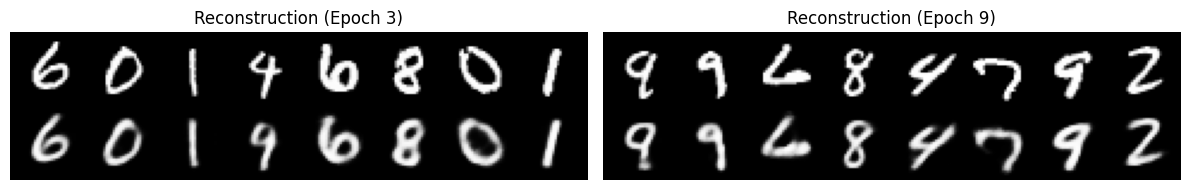

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
img3 = PILImage.open("results/reconstruction_3.png")
axes[0].imshow(np.array(img3), cmap="gray")
axes[0].set_title("Reconstruction (Epoch 3)")
axes[0].axis("off")
img9 = PILImage.open("results/reconstruction_9.png")
axes[1].imshow(np.array(img9), cmap="gray")
axes[1].set_title("Reconstruction (Epoch 9)")
axes[1].axis("off")
plt.tight_layout()

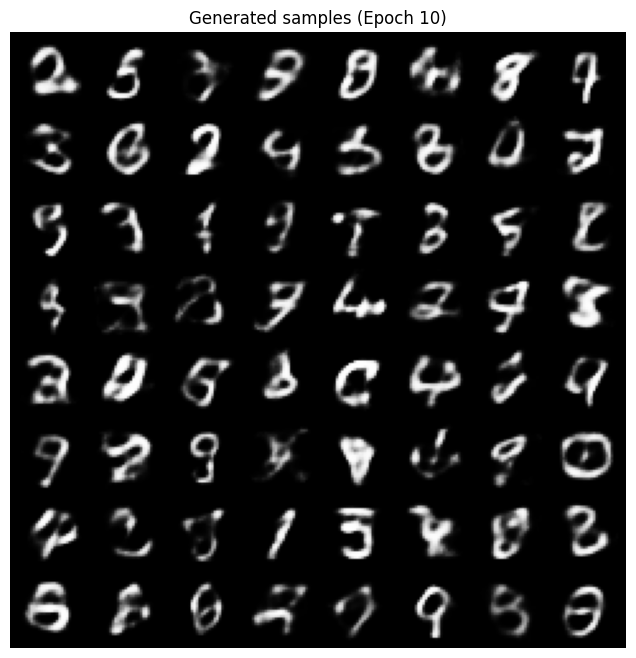

In [13]:
img_sample = PILImage.open("results/sample_10.png")
plt.figure(figsize=(8, 8))
plt.imshow(np.array(img_sample), cmap="gray")
plt.title("Generated samples (Epoch 10)")
plt.axis("off");